In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import cv2

# I. SVD




## Lý thuyết

Cho ma trận $A \in \mathbb{R}^{m \times n}$ có hạng $\text{rank}(A) = r$. Khi đó, tồn tại các ma trận phân tích theo công thức: $$A = U \Sigma V^T $$



*   $U \in \mathbb{R}^{m \times m}$ là ma trận trực giao ($U^T U = I_m$). Các cột của $U$ gọi là vector suy biến trái.
*   $V \in \mathbb{R}^{n \times n}$ là ma trận trực giao ($V^T V = I_n$). Các cột của $V$ gọi là vector suy biến phải.
*   $\Sigma \in \mathbb{R}^{m \times n}$ là ma trận đường chéo chứa các giá trị suy biến $\sigma_i$ trên đường chéo chính, thỏa mãn $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r > 0$ và các phần tử còn lại bằng 0.






Trong `Python`, ta có thể tính SVD bằng cách sử dụng trực tiếp `np.linalg.svd`

In [2]:
A = np.array([[3,3,2], [2, 3, -2]])
U,S,V = np.linalg.svd(A)

Cần lưu ý 2 điều, trong `np.linalg.svd`:
*   S là vector 1D và việc sử dụng `np.diag(S)` chỉ đúng khi A là ma trận vuông.
*   V được trả về là $V^T$ nên không cần thiết phải thực hiện chuyển vị nữa

In [3]:
A_recon = U @ np.diag(S) @ V

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)

In [4]:
print(U.shape, S.shape, V.shape)

(2, 2) (2,) (3, 3)


In [5]:
S_mat = np.zeros(np.shape(A))
np.fill_diagonal(S_mat,S)

A_real_recon = U @ S_mat @ V

In [6]:
print(A)
print(A_real_recon)

[[ 3  3  2]
 [ 2  3 -2]]
[[ 3.  3.  2.]
 [ 2.  3. -2.]]


Text(0.5, 1.0, '\nV')

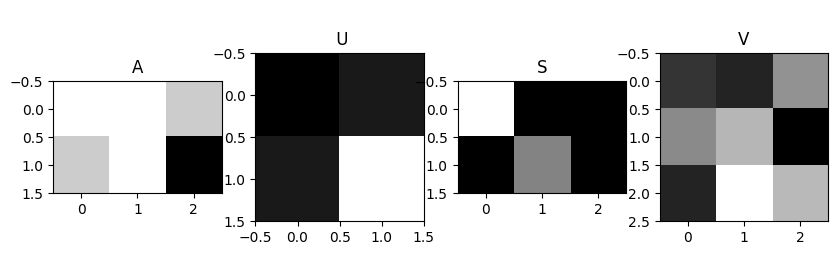

In [7]:
_,axs = plt.subplots(1,4,figsize=(10,6))

axs[0].imshow(A,cmap='gray',aspect='equal')
axs[0].set_title('\nA')

axs[1].imshow(U,cmap='gray',aspect='equal')
axs[1].set_title('\n U')

axs[2].imshow(S_mat,cmap='gray',aspect='equal')
axs[2].set_title('\nS')

axs[3].imshow(V,cmap='gray',aspect='equal')
axs[3].set_title('\nV')

# II. Xấp xỉ ma trận hạng thấp

Phân tích giá trị kỳ dị - SVD của một ma trận $\mathbf{A}$ thường được biểu diễn dưới dạng tổng quát là:
$$\mathbf{A} = \mathbf{U\Sigma V}^\top$$

Tuy nhiên, để hiểu rõ bản chất khi thực hành, chúng ta có thể bóc tách phương trình này để xem xét chi tiết cách ma trận tương tác với các vector. Tương tự như phương trình trị riêng ($\mathbf{Av} = \lambda\mathbf{v}$) mô tả phép biến đổi vector, SVD cũng thực hiện điều này nhưng sử dụng một cặp hai vector độc lập thay vì một vector duy nhất:

$$\mathbf{Av} = \mathbf{u}\sigma$$

$$\mathbf{u}^\top\mathbf{A} = \sigma\mathbf{v}^\top$$

Từ hệ thức trên, nếu ta xét tách biệt từng bộ giá trị riêng lẻ—bao gồm vector kỳ dị trái $\mathbf{u}_i$, vector kỳ dị phải $\mathbf{v}_i$ và đại lượng vô hướng $\sigma_i$—và nhân chúng lại với nhau theo thứ tự cột nhân với hàng (phép tích ngoài), ta sẽ có:

$$\mathbf{u}_i\sigma_i\mathbf{v}_i^\top = \mathbf{A}_i$$

Text(0.5, 1.0, '\nV_1')

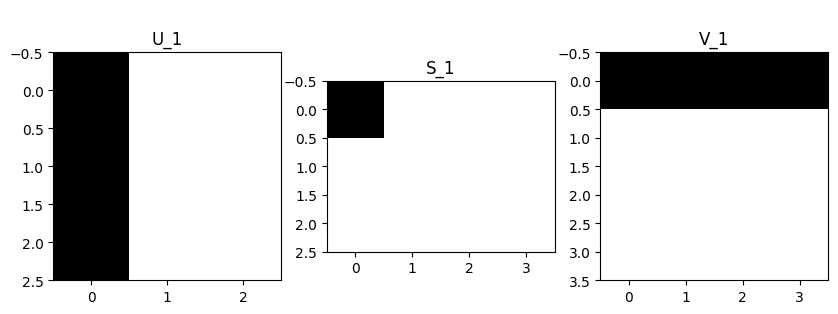

In [8]:
M, N = 3, 4

# U1
U_mask = np.zeros((M, M))
U_mask[:, 0] = 1

# S1
S_mask = np.zeros((M, N))
S_mask[0, 0] = 1

# V1T
VT_mask = np.zeros((N, N))
VT_mask[0, :] = 1

# --fig
_,axs = plt.subplots(1,3,figsize=(10,6))

# U1
axs[0].imshow(U_mask, cmap='gray_r', aspect='equal')
axs[0].set_title('\nU_1')

# S1
axs[1].imshow(S_mask, cmap='gray_r', aspect='equal')
axs[1].set_title('\nS_1')

# V1T
axs[2].imshow(VT_mask, cmap='gray_r', aspect='equal')
axs[2].set_title('\nV_1')

Kết quả của phép toán này luôn tạo ra một ma trận $\mathbf{A}_i$ mang hai đặc điểm quan trọng:
-  có cùng kích thước với ma trận gốc $\mathbf{A}$
-  là một ma trận hạng 1 (rank = 1).

Dựa trên tính chất phân rã này, toàn bộ ma trận gốc $\mathbf{A}$ có thể được biểu diễn một cách trực quan là tổng của nhiều ma trận hạng 1 xếp chồng lên nhau. Cụ thể, ta có thể tái tạo hoàn toàn ma trận gốc bằng cách cộng tất cả các lớp SVD ứng với giá trị kỳ dị $\sigma > 0$. Nếu ma trận có hạng là $r$, phương trình tái tạo sẽ là:

$$
\mathbf{A} = \sum_{i=1}^{r} \mathbf{u}_i\sigma_i\mathbf{v}_i^\top
$$

Trong chuỗi tổng này, mỗi thành phần được kiểm soát độ quan trọng bởi đại lượng $\sigma_i$. Điểm đột phá của cách biểu diễn SVD là chúng ta không nhất thiết phải sử dụng toàn bộ $r$ lớp. Thay vào đó, ta có thể xây dựng một ma trận $\widetilde{\mathbf{A}}$ bằng cách chỉ giữ lại $k$ lớp đầu tiên (với $k < r$). Kỹ thuật này được gọi là xấp xỉ hạng thấp (low-rank approximation) của ma trận $\mathbf{A}$

[[False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]]


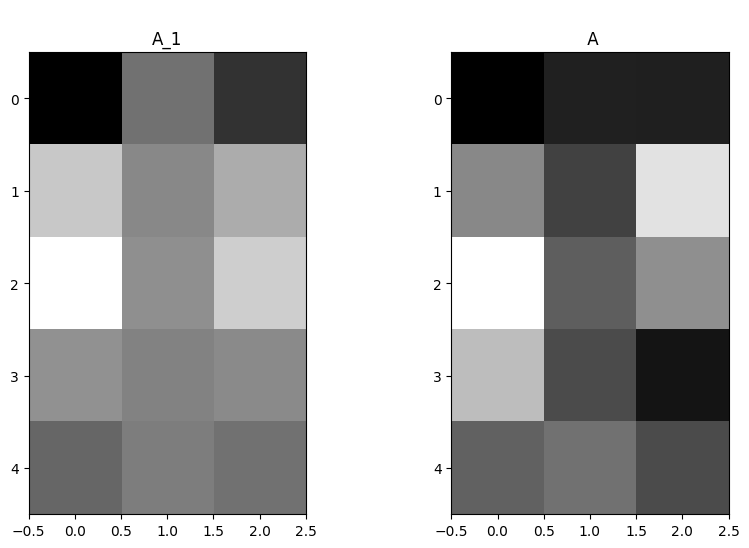

In [9]:
M, N = 5, 3
A_mat = np.random.randn(M, N)
U, S, VT = np.linalg.svd(A_mat)

U_1 = U[:, 0]
S_1 = S[0]
VT_1 = VT[0, :]

A_mat_1 = np.outer(
    U_1 * S_1,
    VT_1)

_,axs = plt.subplots(1,2,figsize=(10,6))

axs[0].imshow(A_mat_1,cmap='gray',aspect='equal')
axs[0].set_title('\nA_1')

axs[1].imshow(A_mat,cmap='gray',aspect='equal')
axs[1].set_title('\n A')

print(np.equal(
    np.round(A_mat_1, 3),
    np.round(A_mat, 3)
))

In [10]:
print(A_mat.shape, A_mat_1.shape)
print(np.linalg.matrix_rank(A_mat), np.linalg.matrix_rank(A_mat_1))

(5, 3) (5, 3)
3 1


In [11]:
rank = np.linalg.matrix_rank(A_mat)
A_vecs = []
for i in range(rank):
    A_vecs.append(
        np.outer(
            U[:, i] * S[i],
            VT[i, :]
        )
    )

A_reconstruct = np.sum(A_vecs, axis=0)

print(np.isclose(
    A_reconstruct,
    A_mat
))

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]]


Để xác định tầm quan trọng của từng thành phần, chúng ta thực hiện chuẩn hóa bình phương của các giá trị suy biến ($\sigma_i^2$). Các giá trị này đại diện cho phương sai (variance) — hay lượng thông tin — mà mỗi thành phần nắm giữ. Cụ thể:

$$
\widetilde{\sigma}_i = \frac{\sigma_i^2}{\sum_{j=1}^{n} \sigma_j^2} \times 100\%
$$   

Phép chuẩn hóa này chuyển đổi các giá trị suy biến sang thang đo phần trăm, giúp ta dễ dàng quan sát và so sánh mức độ đóng góp thông tin của từng rank. Đây là cơ sở để xác định chính xác số lượng layer/rank cần giữ lại nhằm bảo toàn $xx\%$ nội dung (phương sai) của ma trận ban đầu, đồng thời loại bỏ hiệu quả các thành phần nhiễu có năng lượng thấp.

In [12]:
prop_var = S**2 / np.sum(S**2)
cum_var = np.cumsum(prop_var)

threshold = 0.8
k = np.argmax(cum_var >= threshold) + 1

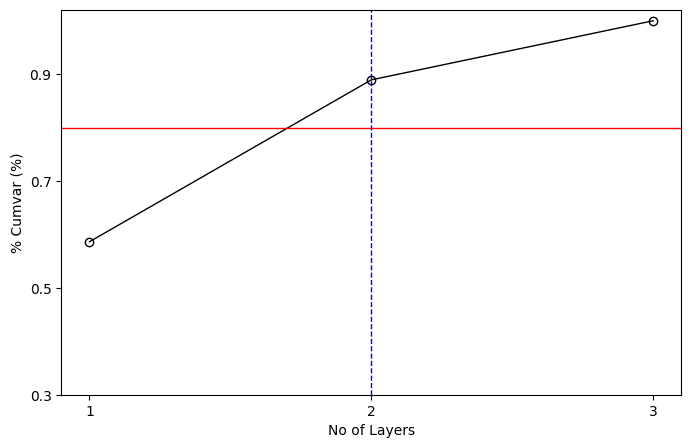

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(1, len(cum_var) + 1), cum_var,
        color='black', linestyle='-', marker='o',
        markerfacecolor='none', markeredgecolor='black', linewidth=1)

ax.set_xlabel('No of Layers')
ax.set_ylabel('% Cumvar (%)')

ax.axhline(y=threshold, color='red', linestyle='-', linewidth=1)
ax.axvline(x=k, color='blue', linestyle='--', linewidth=1)
ax.set_yticks([0.3, 0.5, 0.7, 0.9])
ax.set_xticks([1, 2, 3])

ax.grid(False)
plt.show()

# III. Ví dụ

(741, 1920) 741


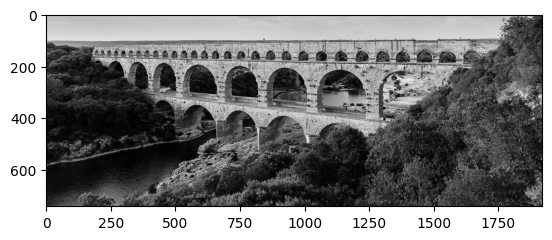

In [14]:
img_path = r"D:\PPS\tuan2\Pont_du_Gard_BLS.jpg"
image = cv2.imread(img_path)
plt.imshow(image)
# image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# plt.imshow(image_rgb)

grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

grayscale = (grayscale - np.min(grayscale)) / (np.max(grayscale) - np.min(grayscale))
plt.imshow(grayscale, cmap='gray')

img_shape = grayscale.shape
img_rank = np.linalg.matrix_rank(grayscale)
print(img_shape, img_rank)

In [15]:
U, S, V = np.linalg.svd(grayscale)
Sigma = np.zeros_like(grayscale)
np.fill_diagonal(Sigma, S)

print(Sigma.shape)

(741, 1920)


In [16]:
# plt.figure(figsize=(12,4))
# plt.plot(S[:30],'ks-',markersize=10)
# plt.xlabel('Component index')
# plt.ylabel('Singular value')
# plt.title('Scree plot of grayscale img')
# plt.grid()
# plt.show()

C:\Users\quanp\AppData\Local\Temp\ipykernel_16112\115300321.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


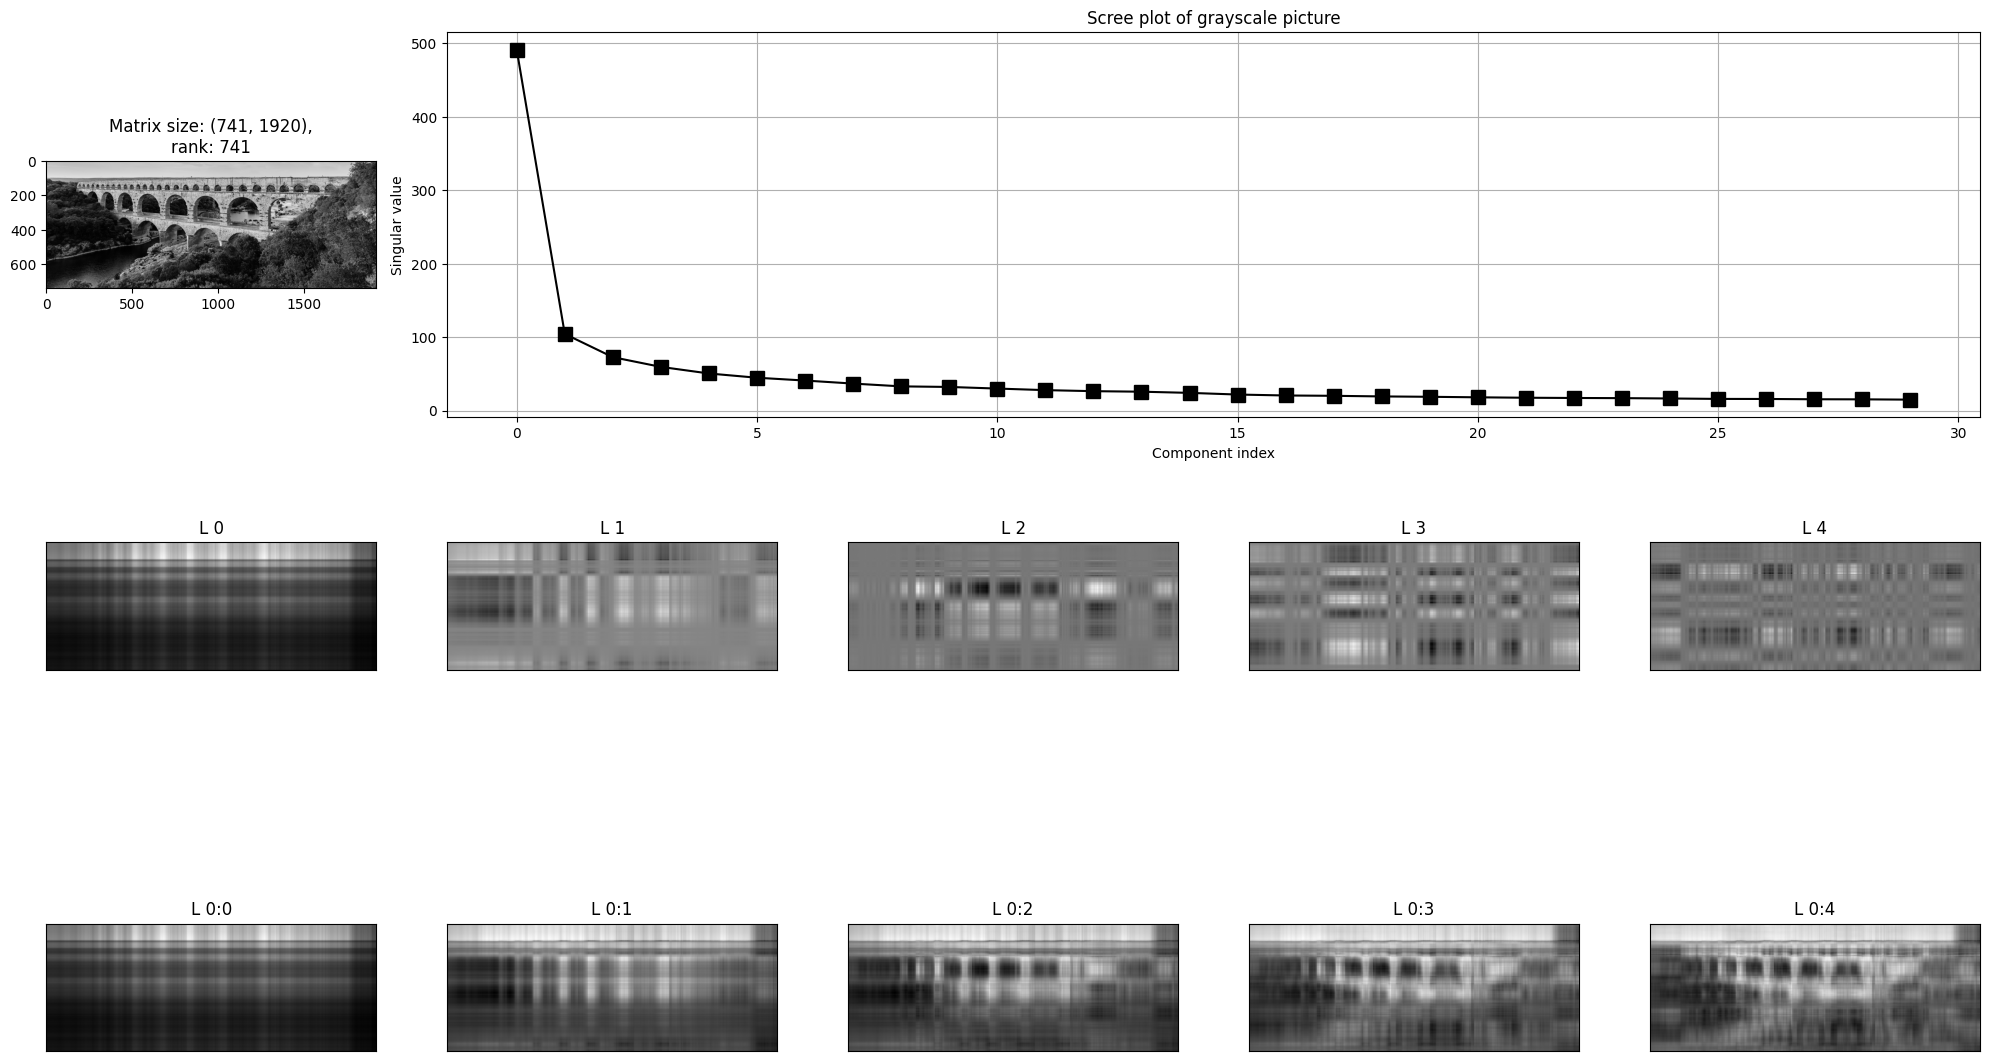

In [17]:
fig = plt.figure(figsize=(20,12), constrained_layout=True)
gs = GridSpec(3,5,figure=fig)

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(grayscale,cmap='gray')
ax1.set_title(f'Matrix size: {grayscale.shape},\nrank: {img_rank}')

ax2 = fig.add_subplot(gs[0,1:])
ax2.plot(S[:30],'ks-',markersize=10)
ax2.set_xlabel('Component index')
ax2.set_ylabel('Singular value')
ax2.set_title('Scree plot of grayscale picture')
ax2.grid()

### get n layers
n_layers = 5
r1_mat = np.zeros((
    n_layers, grayscale.shape[0], grayscale.shape[1]
))

for i in range(n_layers):
    r1_mat[i,:,:] = np.outer(U[:, i], V[i,:]) * S[i]

    # Plot each layer img
    ax = fig.add_subplot(gs[1,i])
    ax.imshow(r1_mat[i,:,:],cmap='gray')
    ax.set_title(f'L {i}')
    ax.set_xticks([]), ax.set_yticks([])

    # Plot the cumulative sum of layers
    ax = fig.add_subplot(gs[2,i])
    ax.imshow(np.sum(r1_mat[:i+1,:,:],axis=0),cmap='gray')
    ax.set_title(f'L 0:{i}')
    ax.set_xticks([]), ax.set_yticks([])

plt.tight_layout()
plt.show()

In [18]:
prop_var = S**2 / np.sum(S**2)
cum_var = np.cumsum(prop_var)

threshold = 0.95
k_optimal = np.argmax(cum_var >= threshold) + 1
print(k_optimal)

78


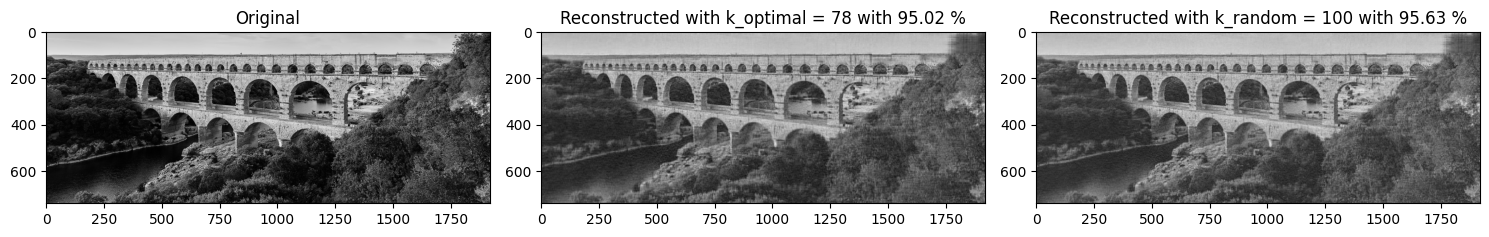

In [19]:
k_random = 100

# Reconstruct with k_optimal and k_random
# with k_optimal
grayscale_opt = U[:,:k_optimal] @ Sigma[:k_optimal,:k_optimal] @ V[:k_optimal, :]
kopt_percent = cum_var[k_optimal-1] * 100
recon_opt = (U.shape[0] * k_optimal + k_optimal * V.shape[1] + k_optimal) * 8/ 1024 / 1024

# with k_random
grayscale_random = U[:,:k_random] @ Sigma[:k_random,:k_random] @ V[:k_random, :]
krandom_percent = cum_var[k_random - 1] * 100
recon_rad = (U.shape[0] * k_random + k_random * V.shape[1] + k_random) * 8/ 1024 / 1024

_,axs = plt.subplots(1,3,figsize=(15,6))
axs[0].imshow(grayscale,cmap='gray')
axs[0].set_title('Original')

axs[1].imshow(grayscale_opt,cmap='gray')
axs[1].set_title(f'Reconstructed with k_optimal = {k_optimal} with {np.round(kopt_percent,2)} %')

axs[2].imshow(grayscale_random,cmap='gray')
axs[2].set_title(f'Reconstructed with k_random = {k_random} with {np.round(krandom_percent,2)} %')

plt.tight_layout()
plt.show()

In [20]:

print(f" Original size : {grayscale.nbytes/1024/1024:.3f} MB")
print(f" Recon 1 size: {recon_opt:.3f} MB")
print(f' \n Compression of {100*(recon_opt)/(grayscale.nbytes /1024/1024):.3f}%')
print(f" Recon 2 size:{recon_rad:.3f} MB")
print(f' \n Compression of {100*(recon_rad)/(grayscale.nbytes/1024/1024):.3f}%')

 Original size : 10.854 MB
 Recon 1 size: 1.584 MB
 
 Compression of 14.594%
 Recon 2 size:2.031 MB
 
 Compression of 18.711%


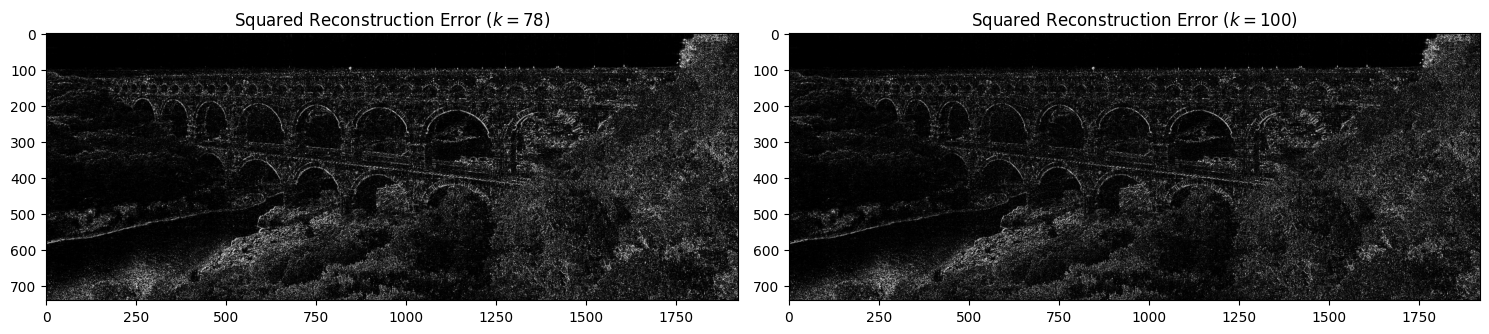

In [21]:
_,axs = plt.subplots(1,2,figsize=(15,6))
axs[0].imshow((grayscale - grayscale_opt) ** 2,cmap='gray', vmin=0,vmax=1e-1)
axs[0].set_title(f'Squared Reconstruction Error ($k={k_optimal}$)')

axs[1].imshow((grayscale - grayscale_random) ** 2,cmap='gray', vmin=0,vmax=1e-1)
axs[1].set_title(f'Squared Reconstruction Error ($k={k_random}$)')

plt.tight_layout()
plt.show()

In [22]:
# comp = range(1, len(S) + 1)
# error_vecs = []

# for i in range(img_rank):
#   temp_recon = U[:, :comp[i]] @ Sigma[:comp[i], :comp[i]] @ V[:comp[i], :]
#   error_vecs.append(
#       np.sqrt(np.sum((grayscale - temp_recon) ** 2))
#   )

In [23]:
# plt.figure(figsize=(10,7))
# plt.plot(comp,error_vecs, 'ks-')
# plt.show()

# Bài tập.

Câu 1:  Sử dụng hàm `np.randn` để tạo một ma trận có kích thước (4,6). Thực hiện SVD trên ma trận này. Xây dựng lại ma trận từ các ma trận $U, S, V$ và trực quan hóa chúng bằng `matplotlib`

[[-0.19072458 -0.23080058 -1.0896171  -0.01813954 -0.08669113 -0.31451315]
 [ 0.09568    -1.42036612  0.89233319  0.78767515 -0.93363041 -0.19383795]
 [ 0.85042852  0.31959813 -0.19354471 -1.00512932 -0.14282839  0.07738578]
 [ 0.29426436  0.24727054  0.6352445   0.75412824 -0.94321322  0.01326062]] 

[[-0.19072458 -0.23080058 -1.0896171  -0.01813954 -0.08669113 -0.31451315]
 [ 0.09568    -1.42036612  0.89233319  0.78767515 -0.93363041 -0.19383795]
 [ 0.85042852  0.31959813 -0.19354471 -1.00512932 -0.14282839  0.07738578]
 [ 0.29426436  0.24727054  0.6352445   0.75412824 -0.94321322  0.01326062]] 



Text(0.5, 1.0, '\nV')

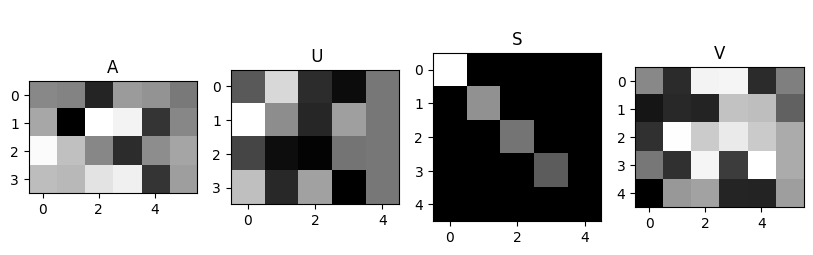

In [24]:
A = np.random.randn(4, 6)

AtA = A.T @ A
ev, V = np.linalg.eigh(AtA)

idx = np.argsort(ev)[::-1]
ev = ev[idx]
V = V[:, idx]

ev[ev < 0] = 0
s = np.sqrt(ev)

nonzero_s = s[s > 1e-10]
U = np.zeros((A.shape[0], len(nonzero_s)))

for i in range(len(nonzero_s)):
    U[:, i] = np.dot(A, V[:, i]) / nonzero_s[i]

Sigma = np.diag(nonzero_s)

V = V[:, :len(nonzero_s)]

A_recon = U @ Sigma @ V.T
print(A, "\n")
print(A_recon, "\n")

_,axs = plt.subplots(1,4,figsize=(10,6))

axs[0].imshow(A,cmap='gray',aspect='equal')
axs[0].set_title('\nA')

axs[1].imshow(U,cmap='gray',aspect='equal')
axs[1].set_title('\n U')

axs[2].imshow(Sigma,cmap='gray',aspect='equal')
axs[2].set_title('\nS')

axs[3].imshow(V.T,cmap='gray',aspect='equal')
axs[3].set_title('\nV')

Câu 2: Thử lại câu 1 nhưng lần này sử dụng [`np.linalg.svd`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html) với `full_matrices = False`.

[[-0.19072458 -0.23080058 -1.0896171  -0.01813954 -0.08669113 -0.31451315]
 [ 0.09568    -1.42036612  0.89233319  0.78767515 -0.93363041 -0.19383795]
 [ 0.85042852  0.31959813 -0.19354471 -1.00512932 -0.14282839  0.07738578]
 [ 0.29426436  0.24727054  0.6352445   0.75412824 -0.94321322  0.01326062]] 

[[-0.19072458 -0.23080058 -1.0896171  -0.01813954 -0.08669113 -0.31451315]
 [ 0.09568    -1.42036612  0.89233319  0.78767515 -0.93363041 -0.19383795]
 [ 0.85042852  0.31959813 -0.19354471 -1.00512932 -0.14282839  0.07738578]
 [ 0.29426436  0.24727054  0.6352445   0.75412824 -0.94321322  0.01326062]] 



Text(0.5, 1.0, '\nV')

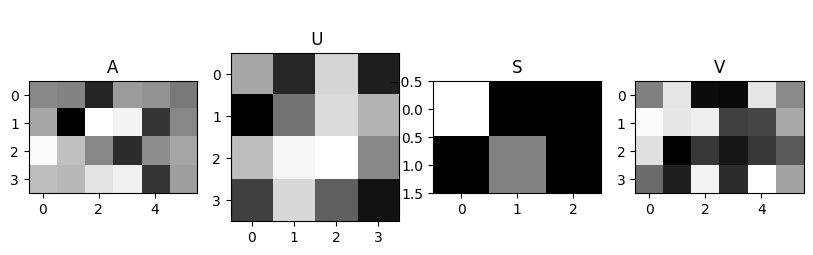

In [25]:
U,S,V = np.linalg.svd(A, full_matrices= False)

Sigma = np.diag(S)

A_recon = U @ Sigma @ V
print(A, "\n")
print(A_recon, "\n")

_,axs = plt.subplots(1,4,figsize=(10,6))

axs[0].imshow(A,cmap='gray',aspect='equal')
axs[0].set_title('\nA')

axs[1].imshow(U,cmap='gray',aspect='equal')
axs[1].set_title('\n U')

axs[2].imshow(S_mat,cmap='gray',aspect='equal')
axs[2].set_title('\nS')

axs[3].imshow(V,cmap='gray',aspect='equal')
axs[3].set_title('\nV')

Câu 3: Ta biết rằng đối với một ma trận đối xứng, các singular values (giá trị suy biến) và các eigenvalues (trị riêng) là giống nhau. Vậy còn các singular vectors và eigenvectors thì sao? Hãy sử dụng Python để trả lời câu hỏi này thông qua các bước sau:

1.   Tạo một ma trận đối xứng bằng phương pháp nhân: $A^T A$ với $A$ là ma trận ngẫu nhiên kích thước $5 \times 5$. Tính eigenvalues và singular values

2.   So sánh singular vectors và eigenvectors của nó. (sử dụng `np.allclose`, `.np.equal` hoặc đơn giản là lấy hai vector trừ nhau)

3.   Tạo một ma trận đối xứng bằng phương pháp cộng: $A^T + A$. Thực hiện lại việc so sánh tương tự.

4.   Nêu nhận xét và giải thích.

In [26]:
#1.
A = np.random.randn(5,5)
B = A.T @ A
print(B, "\n")

eigenvalues, eigenvectors = np.linalg.eigh(B)
i = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[i]
eigenvectors_sorted = eigenvectors[:, i]

U, singular_values, V = np.linalg.svd(B)
print("eigenvalues = ", eigenvalues)
print("singular_values = ", singular_values)

[[ 7.80875412  2.16232293  0.41475904 -1.25970452 -2.21995791]
 [ 2.16232293  0.77204217  0.0760862  -1.05559195 -0.87257551]
 [ 0.41475904  0.0760862   0.85642411  0.29011457  0.40925213]
 [-1.25970452 -1.05559195  0.29011457  5.56893652  3.92711349]
 [-2.21995791 -0.87257551  0.40925213  3.92711349  3.90199211]] 

eigenvalues =  [11.30609611  6.11464469  0.94192515  0.52590198  0.01958111]
singular_values =  [11.30609611  6.11464469  0.94192515  0.52590198  0.01958111]


In [27]:
#2.
print(np.allclose(np.abs(U), np.abs(eigenvectors_sorted)))
print(np.allclose(np.abs(V.T), np.abs(eigenvectors_sorted)))

True
True


In [28]:
#3.
C = A.T + A
print(C, "\n")

eigenvalues, eigenvectors = np.linalg.eigh(C)
i = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[i]
eigenvectors_sorted = eigenvectors[:, i]

U, S, V = np.linalg.svd(C)

print(np.allclose(np.abs(U), np.abs(eigenvectors_sorted)))
print(np.allclose(np.abs(V.T), np.abs(eigenvectors_sorted)))

[[ 2.88176581 -1.09693102  2.61838457  0.23053336  0.70369218]
 [-1.09693102 -0.2796104   1.08264521 -0.35003034  1.10338759]
 [ 2.61838457  1.08264521 -0.22980039 -0.19998763 -0.05065904]
 [ 0.23053336 -0.35003034 -0.19998763  2.83525304 -1.20764214]
 [ 0.70369218  1.10338759 -0.05065904 -1.20764214 -3.46591656]] 

False
False


### Nhận xét
- eigenvectors và singular vectors của ma trận $A^T \cdot A$ bằng nhau
- eigenvectors và singular vectors của ma trận $A^T + A$ không bằng nhau
### Giải thích 
Ma trận $B = A^T A$ luôn là ma trận đối xứng.Theo định nghĩa SVD: Singular vectors của $B$ là các vector riêng (eigenvectors) của $B^T B$. Vì $B$ đối xứng nên $B^T B = B \cdot B = B^2$.\
Vì $B$ và $B^2$ có cùng chung tập hợp các vector riêng. Nên, các vector riêng của $B$ cũng vector riêng của $B^2$, và theo định nghĩa, chúng chính là các singular vectors của $B$.

Câu 4: Xét lại ví dụ trong phần III. Tuy nhiên lần này ta sẽ điều chỉnh đôi chút:

- Tạo ma trận nhiễu 2D Sine Wave dựa trên công thức $Z = \sin(2\pi f(X \cos(\theta) + Y \sin(\theta)))$. Sau đó trộn nhiễu này vào ảnh gốc (có thể dùng lại ảnh từ ví dụ hoặc ảnh nào đó khác). Chọn $f = 0.02$, $\theta = \pi/6$

- Trực quan 3 ảnh ( gốc / nhiễu / trộn).

- Vẽ Scree plot và trực quan hóa như sau:
  - Hiển thị 4 layer đơn lẻ đầu tiên.
  - Hiển thị 4 layer tích lũy đầu tiên.
  - Nhận xét của bạn

- Áp dụng SVD lên trên ảnh nhiễu. Sau đó tái xây dựng lại ảnh gốc. Nếu có thể? ta có thể trích các thành phần chứa nhiễu ra để trực quan không? Nêu và giải thích cách thức bạn ứng dụng SVD để khử nhiễu.

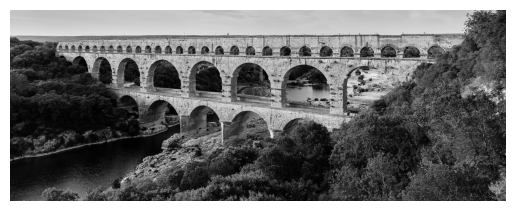

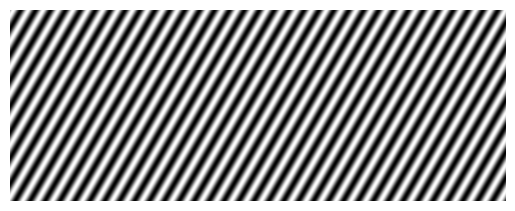

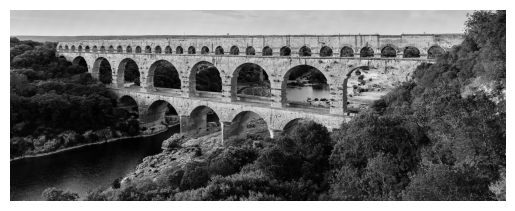

In [29]:
img_path = r"D:\PPS\tuan2\Pont_du_Gard_BLS.jpg"
image = cv2.imread(img_path)

grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(grayscale, cmap='gray')
plt.axis('off')
plt.show()

noise = np.sin(2 * np.pi * 0.02 * (np.arange(image.shape[1]) * np.cos(np.pi/6) + np.arange(image.shape[0])[:, None] * np.sin(np.pi/6)))
plt.imshow(noise, cmap='gray')
plt.axis('off')
plt.show()

noisy_image = grayscale + noise
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')
plt.show()

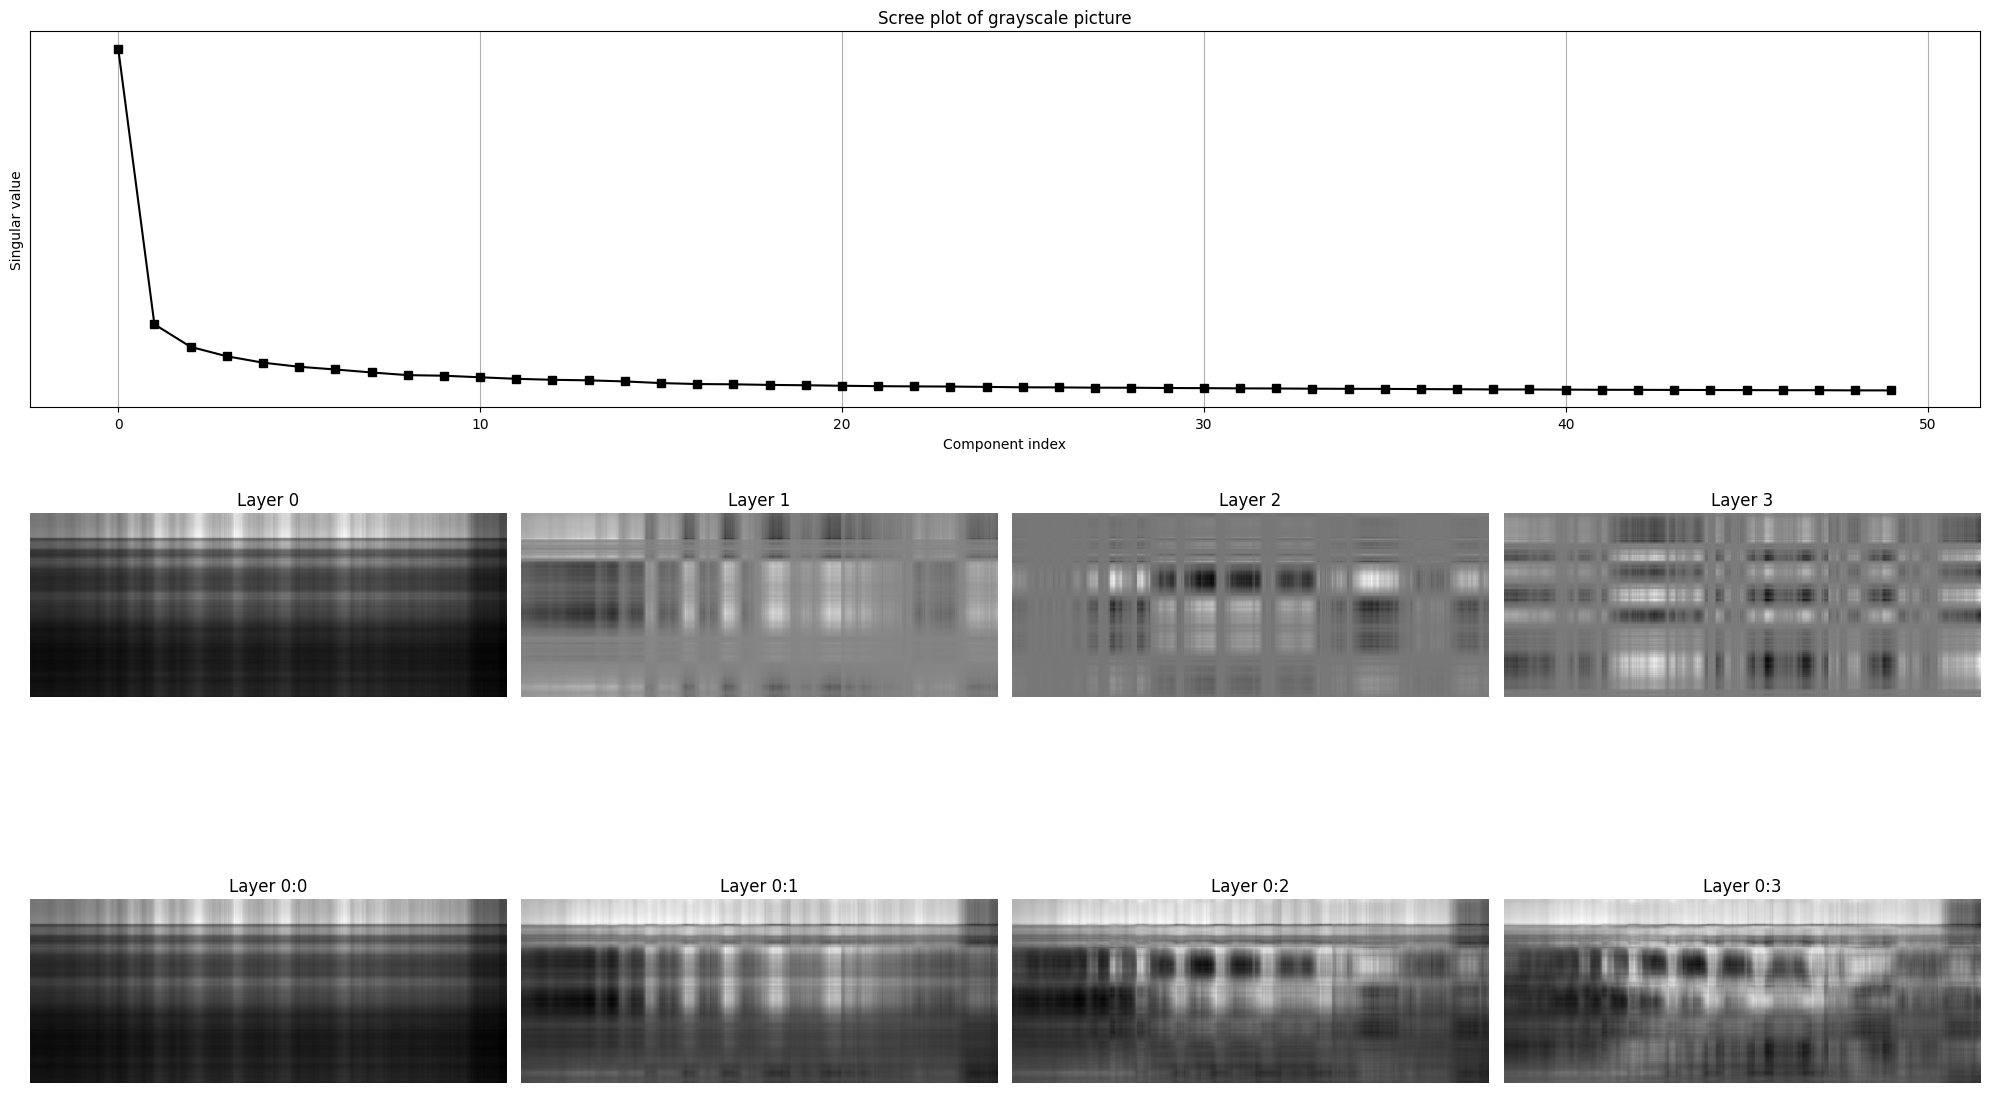

In [30]:
U_noisy, S_noisy, V_noisy = np.linalg.svd(noisy_image, full_matrices= False)

fig = plt.figure(figsize=(20,12))
gs = GridSpec(3,4,figure=fig)

ax = fig.add_subplot(gs[0, :])
ax.plot(S_noisy[:50], 'ks-', markersize=6)
ax.set_xlabel('Component index')
ax.set_ylabel('Singular value')
ax.set_title('Scree plot of grayscale picture')
ax.grid()

n_layers = 4

for i in range(n_layers):
    single_layer = np.outer(U_noisy[:, i], V_noisy[i,:]) * S_noisy[i]

    # Plot each layer img
    ax_single = fig.add_subplot(gs[1,i])
    ax_single.imshow(single_layer, cmap='gray')
    ax_single.set_title(f'Layer {i}')
    ax_single.set_xticks([]), ax.set_yticks([])
    ax_single.axis('off')

    # Plot the cumulative sum of layers
    cummulative_layer = U_noisy[:, :i+1] @ np.diag(S_noisy[:i+1]) @ V_noisy[:i+1, :]
    ax_cummulative = fig.add_subplot(gs[2,i])
    ax_cummulative.imshow(cummulative_layer,cmap='gray')
    ax_cummulative.set_title(f'Layer 0:{i}')
    ax_cummulative.set_xticks([]), ax.set_yticks([])
    ax_cummulative.axis('off')

plt.tight_layout()
plt.show()

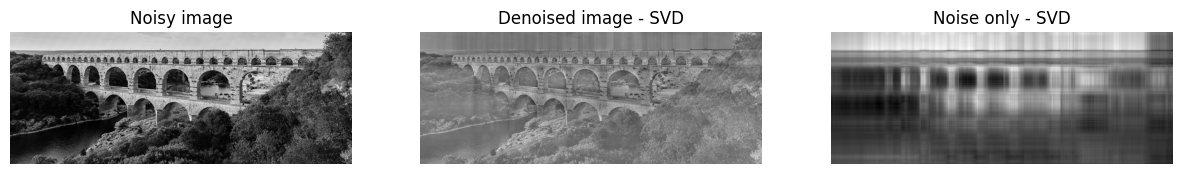

In [31]:
noisy_layers = [0, 1, 2]

S_noise_only = np.zeros_like(S_noisy)
S_noise_only[noisy_layers] = S_noisy[noisy_layers]
noise_only = U_noisy @ np.diag(S_noise_only) @ V_noisy

S_denoised = S_noisy.copy()
S_denoised[noisy_layers] = 0
image_recon = U_noisy @ np.diag(S_denoised) @ V_noisy

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.title('Noisy image')
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Denoised image - SVD')
plt.imshow(image_recon, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Noise only - SVD')
plt.imshow(noise_only, cmap='gray')
plt.axis('off')

plt.show()

Câu 5: Cho một ảnh RGB bất kỳ. Hãy thực hiện SVD trên từng kênh màu để nén ảnh, sau đó tái cấu trúc và hiển thị so sánh các kết quả sau:
- Ảnh gốc.
- Ảnh tái cấu trúc giữ lại 80% phương sai.
- Ảnh tái cấu trúc với số lượng thành phần $k$ ($k$-components) tự chọn.

Yêu cầu: Hiển thị các ảnh trên cùng một figure để dễ dàng so sánh và giải thích lý do bạn chọn giá trị $k$ đó. So sánh tỉ lệ nén và kích thước

In [32]:
img_path = r"D:\PPS\tuan2\Steel-Ball-Run-JoJos-Bizarre-Adventure.jpg"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

r, g, b = cv2.split(image)

u_r, s_r, v_r = np.linalg.svd(r, full_matrices=False)
u_g, s_g, v_g = np.linalg.svd(g, full_matrices=False)
u_b, s_b, v_b = np.linalg.svd(b, full_matrices=False)

r_recon = u_r @ np.diag(s_r) @ v_r
g_recon = u_g @ np.diag(s_g) @ v_g
b_recon = u_b @ np.diag(s_b) @ v_b

r_recon = np.clip(r_recon, 0, 255).astype('uint8')
g_recon = np.clip(g_recon, 0, 255).astype('uint8')
b_recon = np.clip(b_recon, 0, 255).astype('uint8')

image_recon = cv2.merge([r_recon, g_recon, b_recon])


In [33]:
prop_var = s_r**2 / np.sum(s_r**2)
cum_var = np.cumsum(prop_var)
k = np.argmax(cum_var >= 0.8) + 1

r_recon = u_r[:, :k] @ np.diag(s_r[:k]) @ v_r[:k, :]

prop_var = s_g**2 / np.sum(s_g**2)
cum_var = np.cumsum(prop_var)
k = np.argmax(cum_var >= 0.8) + 1

g_recon = u_g[:, :k] @ np.diag(s_g[:k]) @ v_g[:k, :]

prop_var = s_b**2 / np.sum(s_b**2)
cum_var = np.cumsum(prop_var)
k = np.argmax(cum_var >= 0.8) + 1

b_recon = u_b[:, :k] @ np.diag(s_b[:k]) @ v_b[:k, :]

r_recon = np.clip(r_recon, 0, 255).astype('uint8')
g_recon = np.clip(g_recon, 0, 255).astype('uint8')
b_recon = np.clip(b_recon, 0, 255).astype('uint8')

image_80 = cv2.merge([r_recon, g_recon, b_recon])


In [34]:
r_recon = u_r[:, :26] @ np.diag(s_r[:26]) @ v_r[:26, :]
g_recon = u_g[:, :26] @ np.diag(s_g[:26]) @ v_g[:26, :]
b_recon = u_b[:, :26] @ np.diag(s_b[:26]) @ v_b[:26, :]

r_recon = np.clip(r_recon, 0, 255).astype('uint8')
g_recon = np.clip(g_recon, 0, 255).astype('uint8')
b_recon = np.clip(b_recon, 0, 255).astype('uint8')

image_custom = cv2.merge([r_recon, g_recon, b_recon])

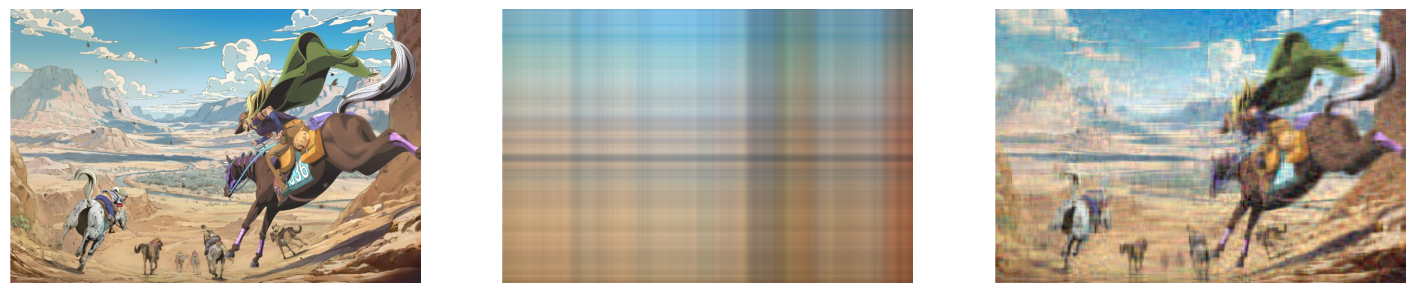

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(image_recon)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_80)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_custom)
plt.axis('off')
plt.show()

### Lý do chọn k = 26
- Tại $k = 26$, ảnh đã giảm được gần 10 lần dung lượng so với ảnh gốc nhưng vẫn giữ được các đặc điểm cấu trúc quan trọng. Các đối tượng trong ảnh hoàn toàn có thể nhận diện được
- Mặc dù các chi tiết tần số cao bị mờ đi do các trị riêng nhỏ bị loại bỏ, nhưng màu sắc và các mảng khối lớn vẫn được bảo toàn tốt.
-  Như đã thấy ở trường hợp 80% phương sai, dù phương sai toán học rất cao nhưng ảnh rất xấu. Việc chọn $k=26$ giúp lấy thêm các thành phần thông tin chi tiết hơn mà vẫn đảm bảo hiệu quả nén cao.